# `fedfred` HTTP Client Benchmark: `httpx` vs `requests` vs `pycurl`

This notebook benchmarks three synchronous HTTP client options against the **actual FRED API**:

1. `httpx`
2. `requests`
3. `pycurl`

The benchmark uses **one separate FRED API key per client** so that rate-limit behavior and throttling risk are isolated by client. API keys are loaded from a local `.env` file and are never printed.

## Benchmark goals

The benchmark measures:

- request latency
- decoded JSON latency
- total wall-clock time
- throughput
- success/failure rate
- HTTP status distribution
- payload size
- row/observation counts
- memory allocation during each workload
- repeated-run stability across 3 independent benchmark series

The notebook is designed for `fedfred` backend decision-making, not synthetic microbenchmarking. It therefore uses real FRED endpoints and real response payloads.

## FRED rate-limit discipline

The main benchmark uses a global request throttle:

- maximum **120 HTTP requests per rolling 60-second window**
- forced **60-second rest interval after every 90 completed benchmark requests**
- one FRED API key per client

This prevents the 1,620-request production benchmark from accidentally concentrating requests into a short interval.


## 0. Required `.env` file

Create a file named `.env` in the same directory as this notebook:

```bash
FRED_API_KEY_HTTPX="your_httpx_key_here"
FRED_API_KEY_REQUESTS="your_requests_key_here"
FRED_API_KEY_PYCURL="your_pycurl_key_here"
```

Each client uses exactly one key:

| Client | Environment variable |
|---|---|
| `httpx` | `FRED_API_KEY_HTTPX` |
| `requests` | `FRED_API_KEY_REQUESTS` |
| `pycurl` | `FRED_API_KEY_PYCURL` |

The notebook also accepts fallback names if you prefer shorter variables:

```bash
FRED_HTTPX_API_KEY="..."
FRED_REQUESTS_API_KEY="..."
FRED_PYCURL_API_KEY="..."
```

Do not commit `.env` to GitHub.

In [11]:
%pip install httpx requests pycurl pandas numpy matplotlib tqdm python-dotenv psutil

Note: you may need to restart the kernel to use updated packages.


## 1. Imports and global configuration

In [12]:
from __future__ import annotations

import dataclasses
import gc
import io
import json
import os
import random
import statistics
import time
import tracemalloc
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Callable, Final, Mapping, Optional
from urllib.parse import urlencode

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

try:
    from dotenv import load_dotenv
except ImportError as exc:
    raise ImportError("Install python-dotenv or load the FRED API keys into the environment manually.") from exc

try:
    import httpx
except ImportError as exc:
    raise ImportError("Install httpx to run the httpx benchmark.") from exc

try:
    import requests
except ImportError as exc:
    raise ImportError("Install requests to run the requests benchmark.") from exc

try:
    import pycurl
except ImportError as exc:
    raise ImportError("Install pycurl to run the pycurl benchmark.") from exc

try:
    import psutil
except ImportError:
    psutil = None

In [ ]:
# -----------------------------------------------------------------------------
# Benchmark scale
# -----------------------------------------------------------------------------
# FAST_DEV_MODE is safe for interactive iteration.
# Set FAST_DEV_MODE = False for a paper/report production run.

FAST_DEV_MODE: bool = True

if FAST_DEV_MODE:
    SERIES_COUNT: int = 3
    RUNS_PER_SERIES: int = 3
    REQUESTS_PER_WORKLOAD: int = 10
else:
    SERIES_COUNT = 3
    RUNS_PER_SERIES = 10
    REQUESTS_PER_WORKLOAD = 25

# -----------------------------------------------------------------------------
# Global FRED rate-limit discipline
# -----------------------------------------------------------------------------
# These values are intentionally conservative. They apply across all clients and
# all API keys because the benchmark should be polite to FRED and reproducible.

MAX_REQUESTS_PER_MINUTE: int = 120
RATE_LIMIT_WINDOW_SECONDS: float = 60.0
REST_EVERY_N_REQUESTS: int = 90
REST_INTERVAL_SECONDS: float = 60.0

# Optional tiny pause after each request. The global limiter above is the main
# protection; this just smooths request bursts inside each 90-request block.
INTER_REQUEST_SLEEP_SECONDS: float = 0.05

TIMEOUT_SECONDS: float = 20.0
RANDOM_SEED: int = 42

FRED_BASE_URL: Final[str] = "https://api.stlouisfed.org/fred"
RESULTS_DIR: Final[Path] = Path("benchmark_results")
FIGURES_DIR: Final[Path] = RESULTS_DIR / "figures"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(
    "Benchmark scale:",
    {
        "FAST_DEV_MODE": FAST_DEV_MODE,
        "SERIES_COUNT": SERIES_COUNT,
        "RUNS_PER_SERIES": RUNS_PER_SERIES,
        "REQUESTS_PER_WORKLOAD": REQUESTS_PER_WORKLOAD,
        "MAX_REQUESTS_PER_MINUTE": MAX_REQUESTS_PER_MINUTE,
        "REST_EVERY_N_REQUESTS": REST_EVERY_N_REQUESTS,
        "REST_INTERVAL_SECONDS": REST_INTERVAL_SECONDS,
        "TIMEOUT_SECONDS": TIMEOUT_SECONDS,
    },
)


Benchmark scale: {'FAST_DEV_MODE': True, 'SERIES_COUNT': 3, 'RUNS_PER_SERIES': 3, 'REQUESTS_PER_WORKLOAD': 10, 'MAX_REQUESTS_PER_MINUTE': 120, 'REST_EVERY_N_REQUESTS': 90, 'REST_INTERVAL_SECONDS': 60.0, 'TIMEOUT_SECONDS': 20.0}


## 2. Load and validate API keys

Keys are loaded from `.env` first, then from the process environment. The values are validated but not printed.

In [14]:
load_dotenv(dotenv_path=Path(".env"), override=False)

CLIENT_KEY_ENV: dict[str, tuple[str, ...]] = {
    "httpx": ("FRED_API_KEY_HTTPX", "FRED_HTTPX_API_KEY"),
    "requests": ("FRED_API_KEY_REQUESTS", "FRED_REQUESTS_API_KEY"),
    "pycurl": ("FRED_API_KEY_PYCURL", "FRED_PYCURL_API_KEY"),
}


def _read_first_env(names: tuple[str, ...]) -> Optional[str]:
    for name in names:
        value = os.environ.get(name)
        if value and value.strip():
            return value.strip()
    return None


API_KEYS: dict[str, str] = {}
missing: list[str] = []

for client_name, env_names in CLIENT_KEY_ENV.items():
    key = _read_first_env(env_names)
    if key is None:
        missing.append(f"{client_name}: one of {env_names}")
    else:
        API_KEYS[client_name] = key

if missing:
    raise RuntimeError(
        "Missing FRED API keys. Add them to .env or your shell environment:\n"
        + "\n".join(missing)
    )

print({client_name: "loaded" for client_name in API_KEYS})

{'httpx': 'loaded', 'requests': 'loaded', 'pycurl': 'loaded'}


## 3. FRED endpoint workloads

The benchmark uses a mix of FRED endpoint types:

| Workload | Endpoint shape | Purpose |
|---|---|---|
| `metadata_small` | `/series` | small JSON metadata payloads |
| `observations_medium` | `/series/observations` with short date window | medium observation payloads |
| `observations_large` | `/series/observations` with long date window | larger time-series payloads |
| `search` | `/series/search` | query-style endpoint |
| `tags` | `/series/tags` | metadata/tag endpoint |
| `mixed` | randomized mix of the above | representative client-library traffic |

The request plan is intentionally deterministic so each client receives the same logical workload.

In [15]:
SERIES_IDS: list[str] = [
    "UNRATE",      # monthly unemployment rate
    "CPIAUCSL",    # monthly CPI
    "FEDFUNDS",    # monthly effective federal funds rate
    "DGS10",       # daily 10-year Treasury yield
    "PAYEMS",      # monthly payroll employment
    "GDPC1",       # quarterly real GDP
    "PCE",         # monthly personal consumption expenditures
    "INDPRO",      # monthly industrial production
    "M2SL",        # monthly M2
    "HOUST",       # monthly housing starts
]

SEARCH_TERMS: list[str] = [
    "inflation",
    "unemployment",
    "interest rate",
    "treasury yield",
    "gross domestic product",
    "industrial production",
]

TAG_SERIES_IDS: list[str] = ["UNRATE", "CPIAUCSL", "DGS10", "FEDFUNDS", "GDPC1"]


def fred_url(path: str) -> str:
    return f"{FRED_BASE_URL}/{path.lstrip('/')}"


@dataclass(frozen=True, slots=True)
class RequestSpec:
    workload_name: str
    endpoint_name: str
    url: str
    params: Mapping[str, Any]


def build_request_specs(workload_name: str, n: int) -> list[RequestSpec]:
    specs: list[RequestSpec] = []
    rng = random.Random(RANDOM_SEED + hash(workload_name) % 10_000)

    for i in range(n):
        series_id = SERIES_IDS[i % len(SERIES_IDS)]

        if workload_name == "metadata_small":
            specs.append(
                RequestSpec(
                    workload_name=workload_name,
                    endpoint_name="series",
                    url=fred_url("series"),
                    params={"series_id": series_id, "file_type": "json"},
                )
            )

        elif workload_name == "observations_medium":
            specs.append(
                RequestSpec(
                    workload_name=workload_name,
                    endpoint_name="series/observations",
                    url=fred_url("series/observations"),
                    params={
                        "series_id": series_id,
                        "observation_start": "2019-01-01",
                        "observation_end": "2024-12-31",
                        "file_type": "json",
                    },
                )
            )

        elif workload_name == "observations_large":
            specs.append(
                RequestSpec(
                    workload_name=workload_name,
                    endpoint_name="series/observations",
                    url=fred_url("series/observations"),
                    params={
                        "series_id": series_id,
                        "observation_start": "1950-01-01",
                        "file_type": "json",
                    },
                )
            )

        elif workload_name == "search":
            search_text = SEARCH_TERMS[i % len(SEARCH_TERMS)]
            specs.append(
                RequestSpec(
                    workload_name=workload_name,
                    endpoint_name="series/search",
                    url=fred_url("series/search"),
                    params={
                        "search_text": search_text,
                        "limit": 25,
                        "file_type": "json",
                    },
                )
            )

        elif workload_name == "tags":
            tag_series_id = TAG_SERIES_IDS[i % len(TAG_SERIES_IDS)]
            specs.append(
                RequestSpec(
                    workload_name=workload_name,
                    endpoint_name="series/tags",
                    url=fred_url("series/tags"),
                    params={"series_id": tag_series_id, "file_type": "json"},
                )
            )

        elif workload_name == "mixed":
            nested_workload = rng.choice(
                ["metadata_small", "observations_medium", "observations_large", "search", "tags"]
            )
            specs.extend(build_request_specs(nested_workload, 1))
            object.__setattr__(specs[-1], "workload_name", "mixed")

        else:
            raise ValueError(f"Unknown workload_name={workload_name!r}")

    return specs


WORKLOAD_NAMES: list[str] = [
    "metadata_small",
    "observations_medium",
    "observations_large",
    "search",
    "tags",
    "mixed",
]

REQUEST_PLANS: dict[str, list[RequestSpec]] = {
    workload_name: build_request_specs(workload_name, REQUESTS_PER_WORKLOAD)
    for workload_name in WORKLOAD_NAMES
}

summary = pd.DataFrame(
    {
        "workload_name": workload,
        "request_count": len(specs),
        "endpoints": ", ".join(sorted({spec.endpoint_name for spec in specs})),
    }
    for workload, specs in REQUEST_PLANS.items()
)
summary

,workload_name,request_count,endpoints
0,metadata_small,10,series
1,observations_medium,10,series/observations
2,observations_large,10,series/observations
3,search,10,series/search
4,tags,10,series/tags
5,mixed,10,"series, series/observations, series/search, se..."


## 4. Client adapters

Each adapter exposes the same call contract:

```python
adapter.get_json(url, params, api_key) -> ClientResponse
```

The adapter returns response metadata and decoded JSON without exposing API keys.

In [16]:
@dataclass(slots=True)
class ClientResponse:
    status_code: Optional[int]
    elapsed_request_seconds: float
    elapsed_decode_seconds: float
    payload_bytes: int
    json_data: Optional[dict[str, Any]]
    error_type: Optional[str] = None
    error_message: Optional[str] = None


class BaseAdapter:
    name: str

    def __enter__(self) -> "BaseAdapter":
        return self

    def __exit__(self, exc_type, exc, tb) -> None:
        self.close()

    def close(self) -> None:
        return None

    def get_json(self, url: str, params: Mapping[str, Any], api_key: str) -> ClientResponse:
        raise NotImplementedError


class HttpxAdapter(BaseAdapter):
    name = "httpx"

    def __init__(self) -> None:
        self._client = httpx.Client(timeout=TIMEOUT_SECONDS)

    def close(self) -> None:
        self._client.close()

    def get_json(self, url: str, params: Mapping[str, Any], api_key: str) -> ClientResponse:
        request_params = dict(params)
        request_params["api_key"] = api_key
        start = time.perf_counter()
        try:
            response = self._client.get(url, params=request_params)
            request_elapsed = time.perf_counter() - start
            raw = response.content
            decode_start = time.perf_counter()
            data = response.json()
            decode_elapsed = time.perf_counter() - decode_start
            return ClientResponse(
                status_code=response.status_code,
                elapsed_request_seconds=request_elapsed,
                elapsed_decode_seconds=decode_elapsed,
                payload_bytes=len(raw),
                json_data=data,
            )
        except Exception as exc:
            return ClientResponse(
                status_code=None,
                elapsed_request_seconds=time.perf_counter() - start,
                elapsed_decode_seconds=0.0,
                payload_bytes=0,
                json_data=None,
                error_type=type(exc).__name__,
                error_message=str(exc)[:300],
            )


class RequestsAdapter(BaseAdapter):
    name = "requests"

    def __init__(self) -> None:
        self._session = requests.Session()

    def close(self) -> None:
        self._session.close()

    def get_json(self, url: str, params: Mapping[str, Any], api_key: str) -> ClientResponse:
        request_params = dict(params)
        request_params["api_key"] = api_key
        start = time.perf_counter()
        try:
            response = self._session.get(url, params=request_params, timeout=TIMEOUT_SECONDS)
            request_elapsed = time.perf_counter() - start
            raw = response.content
            decode_start = time.perf_counter()
            data = response.json()
            decode_elapsed = time.perf_counter() - decode_start
            return ClientResponse(
                status_code=response.status_code,
                elapsed_request_seconds=request_elapsed,
                elapsed_decode_seconds=decode_elapsed,
                payload_bytes=len(raw),
                json_data=data,
            )
        except Exception as exc:
            return ClientResponse(
                status_code=None,
                elapsed_request_seconds=time.perf_counter() - start,
                elapsed_decode_seconds=0.0,
                payload_bytes=0,
                json_data=None,
                error_type=type(exc).__name__,
                error_message=str(exc)[:300],
            )


class PycurlAdapter(BaseAdapter):
    name = "pycurl"

    def __init__(self) -> None:
        self._curl = pycurl.Curl()
        self._curl.setopt(pycurl.FOLLOWLOCATION, 1)
        self._curl.setopt(pycurl.CONNECTTIMEOUT_MS, int(TIMEOUT_SECONDS * 1000))
        self._curl.setopt(pycurl.TIMEOUT_MS, int(TIMEOUT_SECONDS * 1000))
        self._curl.setopt(pycurl.NOSIGNAL, 1)
        self._curl.setopt(pycurl.USERAGENT, "fedfred-http-client-benchmark/1.0")

    def close(self) -> None:
        self._curl.close()

    def get_json(self, url: str, params: Mapping[str, Any], api_key: str) -> ClientResponse:
        request_params = dict(params)
        request_params["api_key"] = api_key
        full_url = f"{url}?{urlencode(request_params)}"
        buffer = io.BytesIO()
        start = time.perf_counter()
        try:
            self._curl.setopt(pycurl.URL, full_url.encode("utf-8"))
            self._curl.setopt(pycurl.WRITEDATA, buffer)
            self._curl.perform()
            request_elapsed = time.perf_counter() - start
            status_code = int(self._curl.getinfo(pycurl.RESPONSE_CODE))
            raw = buffer.getvalue()
            decode_start = time.perf_counter()
            data = json.loads(raw.decode("utf-8"))
            decode_elapsed = time.perf_counter() - decode_start
            return ClientResponse(
                status_code=status_code,
                elapsed_request_seconds=request_elapsed,
                elapsed_decode_seconds=decode_elapsed,
                payload_bytes=len(raw),
                json_data=data,
            )
        except Exception as exc:
            return ClientResponse(
                status_code=None,
                elapsed_request_seconds=time.perf_counter() - start,
                elapsed_decode_seconds=0.0,
                payload_bytes=len(buffer.getvalue()),
                json_data=None,
                error_type=type(exc).__name__,
                error_message=str(exc)[:300],
            )


ADAPTER_FACTORIES: dict[str, type[BaseAdapter]] = {
    "httpx": HttpxAdapter,
    "requests": RequestsAdapter,
    "pycurl": PycurlAdapter,
}

list(ADAPTER_FACTORIES)

['httpx', 'requests', 'pycurl']

## 5. Result schema and helper functions

In [17]:
@dataclass(slots=True)
class BenchmarkResult:
    client_name: str
    workload_name: str
    endpoint_name: str
    series: int
    run: int
    request_index: int
    status_code: Optional[int]
    success: bool
    error_type: Optional[str]
    error_message: Optional[str]
    request_seconds: float
    decode_seconds: float
    total_seconds: float
    payload_bytes: int
    observation_count: Optional[int]
    result_count: Optional[int]
    allocated_bytes_current: int
    allocated_bytes_peak: int
    rss_delta_bytes: Optional[int]


def extract_counts(data: Optional[dict[str, Any]]) -> tuple[Optional[int], Optional[int]]:
    if data is None:
        return None, None

    observations = data.get("observations")
    if isinstance(observations, list):
        return len(observations), None

    seriess = data.get("seriess")
    if isinstance(seriess, list):
        return None, len(seriess)

    tags = data.get("tags")
    if isinstance(tags, list):
        return None, len(tags)

    return None, None


def process_rss_bytes() -> Optional[int]:
    if psutil is None:
        return None
    return psutil.Process(os.getpid()).memory_info().rss



class FredRateLimiter:
    """Global rate limiter for real FRED API benchmark requests.

    The limiter enforces two independent policies:

    1. At most ``max_requests`` in any rolling ``window_seconds`` interval.
    2. A forced ``rest_seconds`` pause after every ``rest_every`` completed requests.

    The second policy is intentionally stricter than a pure rolling-window limiter
    because long production runs are easier to reason about when broken into
    conservative request blocks.
    """

    def __init__(
        self,
        *,
        max_requests: int,
        window_seconds: float,
        rest_every: int,
        rest_seconds: float,
    ) -> None:
        if max_requests <= 0:
            raise ValueError("max_requests must be positive")
        if window_seconds <= 0:
            raise ValueError("window_seconds must be positive")
        if rest_every <= 0:
            raise ValueError("rest_every must be positive")
        if rest_seconds < 0:
            raise ValueError("rest_seconds cannot be negative")

        self.max_requests = max_requests
        self.window_seconds = window_seconds
        self.rest_every = rest_every
        self.rest_seconds = rest_seconds
        self._request_times: list[float] = []
        self.completed_requests = 0

    def wait_before_request(self) -> None:
        """Block until another request can be made under the rolling limit."""
        now = time.monotonic()
        cutoff = now - self.window_seconds
        self._request_times = [t for t in self._request_times if t > cutoff]

        if len(self._request_times) >= self.max_requests:
            sleep_for = self.window_seconds - (now - self._request_times[0])
            if sleep_for > 0:
                time.sleep(sleep_for)

        self._request_times.append(time.monotonic())

    def record_completed_request(self) -> None:
        """Record a completed request and apply block-level rest if required."""
        self.completed_requests += 1
        if self.completed_requests % self.rest_every == 0:
            print(
                f"Completed {self.completed_requests:,} benchmark requests; "
                f"resting for {self.rest_seconds:.0f} seconds."
            )
            if self.rest_seconds > 0:
                time.sleep(self.rest_seconds)


def run_one_request(
    adapter: BaseAdapter,
    client_name: str,
    api_key: str,
    spec: RequestSpec,
    series: int,
    run: int,
    request_index: int,
) -> BenchmarkResult:
    gc.collect()
    rss_before = process_rss_bytes()
    tracemalloc.start()
    total_start = time.perf_counter()
    response = adapter.get_json(spec.url, spec.params, api_key)
    total_elapsed = time.perf_counter() - total_start
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    rss_after = process_rss_bytes()

    observation_count, result_count = extract_counts(response.json_data)
    success = response.error_type is None and response.status_code == 200

    return BenchmarkResult(
        client_name=client_name,
        workload_name=spec.workload_name,
        endpoint_name=spec.endpoint_name,
        series=series,
        run=run,
        request_index=request_index,
        status_code=response.status_code,
        success=success,
        error_type=response.error_type,
        error_message=response.error_message,
        request_seconds=response.elapsed_request_seconds,
        decode_seconds=response.elapsed_decode_seconds,
        total_seconds=total_elapsed,
        payload_bytes=response.payload_bytes,
        observation_count=observation_count,
        result_count=result_count,
        allocated_bytes_current=current,
        allocated_bytes_peak=peak,
        rss_delta_bytes=None if rss_before is None or rss_after is None else rss_after - rss_before,
    )


def run_client_workload(
    client_name: str,
    workload_name: str,
    series: int,
    run: int,
    rate_limiter: FredRateLimiter,
) -> list[BenchmarkResult]:
    adapter_cls = ADAPTER_FACTORIES[client_name]
    api_key = API_KEYS[client_name]
    specs = REQUEST_PLANS[workload_name]
    results: list[BenchmarkResult] = []

    with adapter_cls() as adapter:
        for request_index, spec in enumerate(specs, start=1):
            rate_limiter.wait_before_request()
            results.append(
                run_one_request(
                    adapter=adapter,
                    client_name=client_name,
                    api_key=api_key,
                    spec=spec,
                    series=series,
                    run=run,
                    request_index=request_index,
                )
            )
            rate_limiter.record_completed_request()
            if INTER_REQUEST_SLEEP_SECONDS > 0:
                time.sleep(INTER_REQUEST_SLEEP_SECONDS)

    return results

## 6. Preflight API validation

This cell makes one request per client using that client's own API key. If any key is invalid, fix the `.env` file before running the full benchmark.

In [18]:
preflight_rows: list[dict[str, Any]] = []

for client_name, adapter_cls in ADAPTER_FACTORIES.items():
    spec = RequestSpec(
        workload_name="preflight",
        endpoint_name="series",
        url=fred_url("series"),
        params={"series_id": "UNRATE", "file_type": "json"},
    )
    with adapter_cls() as adapter:
        response = adapter.get_json(spec.url, spec.params, API_KEYS[client_name])
    preflight_rows.append(
        {
            "client_name": client_name,
            "status_code": response.status_code,
            "error_type": response.error_type,
            "payload_bytes": response.payload_bytes,
            "request_seconds": response.elapsed_request_seconds,
            "decode_seconds": response.elapsed_decode_seconds,
            "json_keys": sorted(response.json_data.keys()) if isinstance(response.json_data, dict) else None,
        }
    )

preflight_df = pd.DataFrame(preflight_rows)
preflight_df

,client_name,status_code,error_type,payload_bytes,request_seconds,decode_seconds,json_keys
0,httpx,200,None,1036,0.148604,0.000045,"[realtime_end, realtime_start, seriess]"
1,requests,200,None,1036,0.137183,0.000037,"[realtime_end, realtime_start, seriess]"
2,pycurl,200,None,1036,0.114571,0.000050,"[realtime_end, realtime_start, seriess]"


## 7. Full synchronous benchmark

This cell performs the main real-FRED benchmark with global rate-limit discipline.

The request count is:

```text
clients × workloads × series × runs × requests_per_workload
```

The benchmark enforces:

```text
maximum 120 requests per rolling 60-second window
60-second rest interval after every 90 completed benchmark requests
```

For a 1,620-request production run, the forced rest intervals alone imply roughly 18 minutes of rest time before ordinary request latency and rolling-window sleeps are included.


In [19]:
total_requests = (
    len(ADAPTER_FACTORIES)
    * len(WORKLOAD_NAMES)
    * SERIES_COUNT
    * RUNS_PER_SERIES
    * REQUESTS_PER_WORKLOAD
)

forced_rest_count = total_requests // REST_EVERY_N_REQUESTS
forced_rest_seconds = forced_rest_count * REST_INTERVAL_SECONDS
rolling_limit_floor_seconds = (total_requests / MAX_REQUESTS_PER_MINUTE) * RATE_LIMIT_WINDOW_SECONDS

print(f"Planned total HTTP requests: {total_requests:,}")
print(
    "Rate policy:",
    {
        "MAX_REQUESTS_PER_MINUTE": MAX_REQUESTS_PER_MINUTE,
        "RATE_LIMIT_WINDOW_SECONDS": RATE_LIMIT_WINDOW_SECONDS,
        "REST_EVERY_N_REQUESTS": REST_EVERY_N_REQUESTS,
        "REST_INTERVAL_SECONDS": REST_INTERVAL_SECONDS,
    },
)
print(f"Forced 60-second rest intervals: {forced_rest_count:,}")
print(f"Forced rest time only: {forced_rest_seconds / 60:.1f} minutes")
print(f"Rolling-limit theoretical lower bound: {rolling_limit_floor_seconds / 60:.1f} minutes")
print(
    "Practical runtime will be higher because it also includes request latency, JSON decode time, "
    "tracemalloc overhead, optional inter-request sleeps, and non-200 retry-free failures."
)


Planned total HTTP requests: 1,620
Rate policy: {'MAX_REQUESTS_PER_MINUTE': 120, 'RATE_LIMIT_WINDOW_SECONDS': 60.0, 'REST_EVERY_N_REQUESTS': 90, 'REST_INTERVAL_SECONDS': 60.0}
Forced 60-second rest intervals: 18
Forced rest time only: 18.0 minutes
Rolling-limit theoretical lower bound: 13.5 minutes
Practical runtime will be higher because it also includes request latency, JSON decode time, tracemalloc overhead, optional inter-request sleeps, and non-200 retry-free failures.


In [20]:
sync_results: list[BenchmarkResult] = []

rate_limiter = FredRateLimiter(
    max_requests=MAX_REQUESTS_PER_MINUTE,
    window_seconds=RATE_LIMIT_WINDOW_SECONDS,
    rest_every=REST_EVERY_N_REQUESTS,
    rest_seconds=REST_INTERVAL_SECONDS,
)

for client_name in tqdm(list(ADAPTER_FACTORIES), desc="clients"):
    for workload_name in tqdm(WORKLOAD_NAMES, desc=f"{client_name} workloads", leave=False):
        for series in range(1, SERIES_COUNT + 1):
            for run in range(1, RUNS_PER_SERIES + 1):
                sync_results.extend(
                    run_client_workload(
                        client_name=client_name,
                        workload_name=workload_name,
                        series=series,
                        run=run,
                        rate_limiter=rate_limiter,
                    )
                )

sync_df = pd.DataFrame(dataclasses.asdict(row) for row in sync_results)
sync_path = RESULTS_DIR / "http_clients_real_fred_sync_results.csv"
sync_df.to_csv(sync_path, index=False)

print(f"Saved: {sync_path}")
print(f"Completed benchmark requests: {rate_limiter.completed_requests:,}")
sync_df.head()


clients:   0%|          | 0/3 [00:00<?, ?it/s]

Completed 90 benchmark requests; resting for 60 seconds.


Completed 180 benchmark requests; resting for 60 seconds.


Completed 270 benchmark requests; resting for 60 seconds.


Completed 360 benchmark requests; resting for 60 seconds.


...

Completed 1,530 benchmark requests; resting for 60 seconds.


Completed 1,620 benchmark requests; resting for 60 seconds.


clients: 100%|██████████| 3/3 [25:32<00:00, 510.70s/it]

Saved: benchmark_results/http_clients_real_fred/http_clients_real_fred_sync_results.csv
Completed benchmark requests: 1,620


,client_name,workload_name,endpoint_name,series,run,request_index,status_code,success,error_type,error_message,request_seconds,decode_seconds,total_seconds,payload_bytes,observation_count,result_count,allocated_bytes_current,allocated_bytes_peak,rss_delta_bytes
0,httpx,metadata_small,series,1,1,1,200,True,None,None,0.129406,0.000054,0.129472,1036,NaN,1.0,10700821,14996345,32768
1,httpx,metadata_small,series,1,1,2,200,True,None,None,0.084679,0.000046,0.084741,3159,NaN,1.0,23172,76286,0
2,httpx,metadata_small,series,1,1,3,200,True,None,None,0.097946,0.000045,0.098004,4435,NaN,1.0,25600,76278,0
3,httpx,metadata_small,series,1,1,4,200,True,None,None,0.073875,0.000038,0.073925,1054,NaN,1.0,19148,76272,0
4,httpx,metadata_small,series,1,1,5,200,True,None,None,0.137864,0.000040,0.137914,2179,NaN,1.0,21215,76274,0


## 8. Quality-control checks

Before interpreting latency, verify that failures and non-200 responses are not dominating one client.

In [21]:
status_summary = (
    sync_df.groupby(["client_name", "status_code"], dropna=False)
    .size()
    .reset_index(name="count")
    .sort_values(["client_name", "status_code"])
)
status_summary.to_csv(RESULTS_DIR / "status_summary.csv", index=False)
status_summary

,client_name,status_code,count
0,httpx,200,526
1,httpx,500,14
2,pycurl,200,535
3,pycurl,500,5
4,requests,200,540


In [22]:
error_summary = (
    sync_df.loc[~sync_df["success"]]
    .groupby(["client_name", "workload_name", "status_code", "error_type"], dropna=False)
    .size()
    .reset_index(name="count")
    .sort_values(["client_name", "workload_name", "count"], ascending=[True, True, False])
)
error_summary.to_csv(RESULTS_DIR / "error_summary.csv", index=False)
error_summary

,client_name,workload_name,status_code,error_type,count
0,httpx,tags,500,NaN,14
1,pycurl,search,500,NaN,5


## 9. Aggregate metrics

The primary latency metric is `total_seconds`, which includes request execution and JSON decoding. `request_seconds` and `decode_seconds` are also retained to separate network/client latency from parser overhead.

In [23]:
def p95(series: pd.Series) -> float:
    return float(series.quantile(0.95))


success_df = sync_df[sync_df["success"]].copy()

aggregate = (
    success_df.groupby(["client_name", "workload_name"])
    .agg(
        requests=("total_seconds", "size"),
        mean_total_ms=("total_seconds", lambda s: float(s.mean() * 1_000)),
        median_total_ms=("total_seconds", lambda s: float(s.median() * 1_000)),
        p95_total_ms=("total_seconds", lambda s: float(p95(s) * 1_000)),
        mean_request_ms=("request_seconds", lambda s: float(s.mean() * 1_000)),
        mean_decode_ms=("decode_seconds", lambda s: float(s.mean() * 1_000)),
        mean_payload_kb=("payload_bytes", lambda s: float(s.mean() / 1024)),
        mean_peak_alloc_kb=("allocated_bytes_peak", lambda s: float(s.mean() / 1024)),
        mean_observations=("observation_count", "mean"),
        mean_results=("result_count", "mean"),
    )
    .reset_index()
)

aggregate.to_csv(RESULTS_DIR / "aggregate_metrics.csv", index=False)
aggregate

,client_name,workload_name,requests,mean_total_ms,median_total_ms,p95_total_ms,mean_request_ms,mean_decode_ms,mean_payload_kb,mean_peak_alloc_kb,mean_observations,mean_results
0,httpx,metadata_small,90,133.877196,97.779042,321.045580,133.820320,0.044168,1.562988,236.592187,NaN,1.000000
1,httpx,mixed,90,132.798790,109.521021,297.600302,131.336777,1.445105,24.743164,176.105599,493.5,13.333333
2,httpx,observations_large,90,138.402098,124.756124,230.676119,130.332981,8.047920,224.051953,1376.430187,2403.1,NaN
3,httpx,observations_medium,90,180.642118,121.602812,465.737894,179.852673,0.775907,20.462598,157.561024,216.6,NaN
4,httpx,search,90,443.723370,114.228979,2447.222591,443.273881,0.437025,28.567285,129.090723,NaN,25.000000
5,httpx,tags,76,166.229613,114.242708,277.439761,166.051927,0.162105,1.755962,75.021279,NaN,12.789474
6,pycurl,metadata_small,90,106.912812,91.578813,162.663352,106.788022,0.063095,1.562988,8.219488,NaN,1.000000
7,pycurl,mixed,90,118.033185,105.238354,181.398677,116.632733,1.330205,24.743164,139.253277,493.5,13.333333
8,pycurl,observations_large,90,168.728344,135.846458,350.375466,158.227693,10.427145,224.051953,1365.074685,2403.1,NaN
9,pycurl,observations_medium,90,207.426744,140.437375,475.265240,205.894190,1.448159,20.462598,126.527257,216.6,NaN


In [24]:
client_summary = (
    sync_df.groupby("client_name")
    .agg(
        total_requests=("success", "size"),
        successes=("success", "sum"),
        failures=("success", lambda s: int((~s).sum())),
        success_rate=("success", "mean"),
    )
    .reset_index()
)

client_latency = (
    success_df.groupby("client_name")
    .agg(
        mean_total_ms=("total_seconds", lambda s: float(s.mean() * 1_000)),
        median_total_ms=("total_seconds", lambda s: float(s.median() * 1_000)),
        p95_total_ms=("total_seconds", lambda s: float(p95(s) * 1_000)),
        mean_request_ms=("request_seconds", lambda s: float(s.mean() * 1_000)),
        mean_decode_ms=("decode_seconds", lambda s: float(s.mean() * 1_000)),
        mean_payload_kb=("payload_bytes", lambda s: float(s.mean() / 1024)),
        mean_peak_alloc_kb=("allocated_bytes_peak", lambda s: float(s.mean() / 1024)),
    )
    .reset_index()
)

client_overview = client_summary.merge(client_latency, on="client_name", how="left")
client_overview.to_csv(RESULTS_DIR / "client_overview.csv", index=False)
client_overview

,client_name,total_requests,successes,failures,success_rate,mean_total_ms,median_total_ms,p95_total_ms,mean_request_ms,mean_decode_ms,mean_payload_kb,mean_peak_alloc_kb
0,httpx,540,526,14,0.974074,200.158502,113.517083,444.020928,198.280310,1.862797,51.479795,366.011011
1,pycurl,540,535,5,0.990741,174.950678,115.424750,292.283296,172.494216,2.384008,50.410215,294.975925
2,requests,540,540,0,1.000000,120.020793,105.564187,182.417035,117.707984,2.281492,50.190837,315.735822


## 10. Figures

The figures are saved under:

```text
benchmark_results/http_clients_real_fred/figures/
```

In [25]:
def savefig(name: str) -> Path:
    path = FIGURES_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    return path


def bar_plot(df: pd.DataFrame, x: str, y: str, title: str, ylabel: str, filename: str, hue: Optional[str] = None) -> Path:
    fig, ax = plt.subplots(figsize=(10, 6))
    if hue is None:
        ax.bar(df[x].astype(str), df[y])
        ax.set_xlabel(x)
    else:
        pivot = df.pivot(index=x, columns=hue, values=y)
        pivot.plot(kind="bar", ax=ax)
        ax.set_xlabel(x)
        ax.legend(title=hue)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=35)
    path = savefig(filename)
    plt.show()
    return path

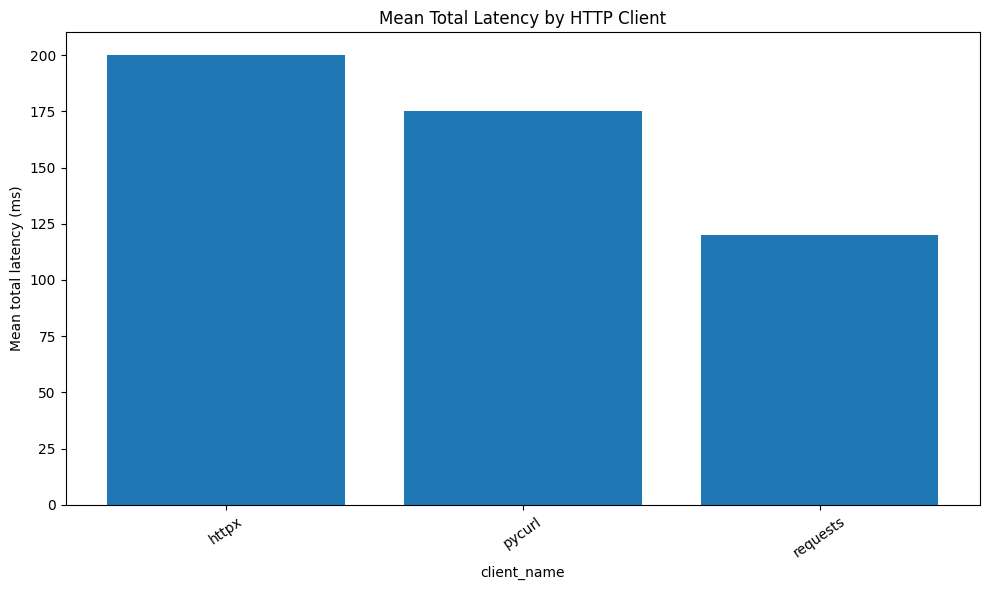

PosixPath('benchmark_results/http_clients_real_fred/figures/mean_total_latency_by_client.png')

In [26]:
bar_plot(
    client_overview,
    x="client_name",
    y="mean_total_ms",
    title="Mean Total Latency by HTTP Client",
    ylabel="Mean total latency (ms)",
    filename="mean_total_latency_by_client.png",
)

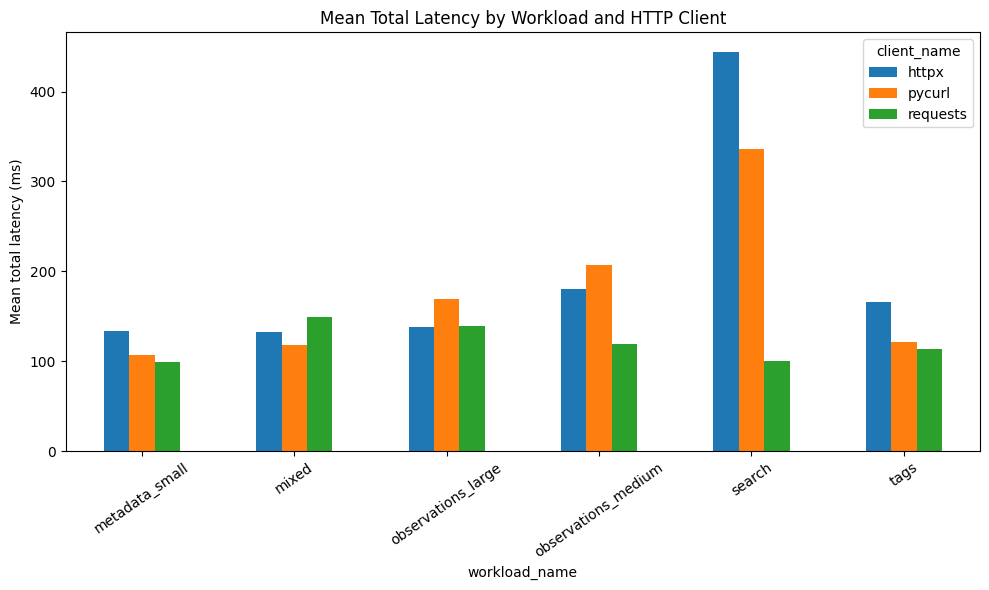

PosixPath('benchmark_results/http_clients_real_fred/figures/mean_total_latency_by_workload.png')

In [27]:
bar_plot(
    aggregate,
    x="workload_name",
    y="mean_total_ms",
    hue="client_name",
    title="Mean Total Latency by Workload and HTTP Client",
    ylabel="Mean total latency (ms)",
    filename="mean_total_latency_by_workload.png",
)

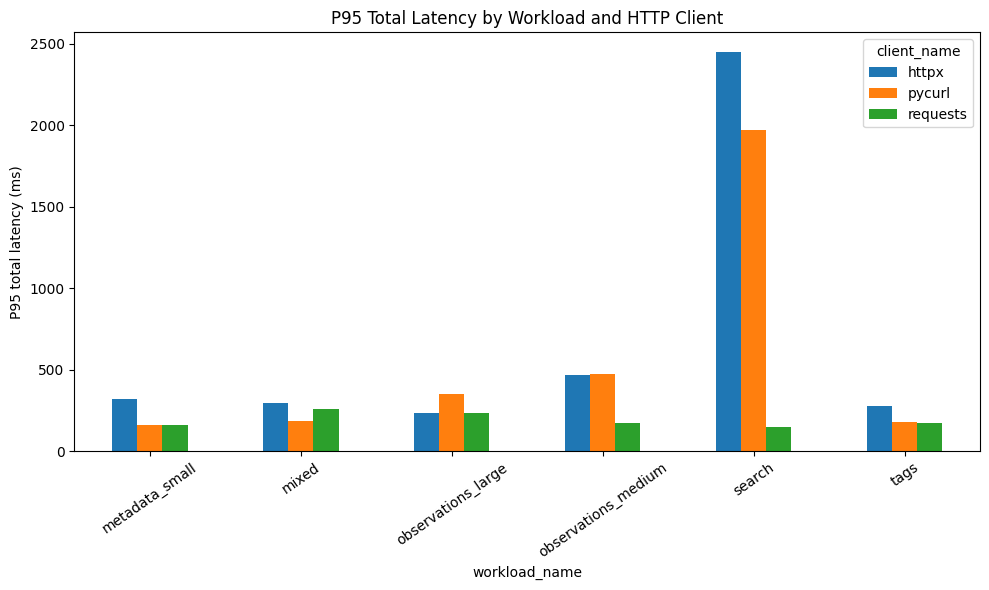

PosixPath('benchmark_results/http_clients_real_fred/figures/p95_total_latency_by_workload.png')

In [28]:
bar_plot(
    aggregate,
    x="workload_name",
    y="p95_total_ms",
    hue="client_name",
    title="P95 Total Latency by Workload and HTTP Client",
    ylabel="P95 total latency (ms)",
    filename="p95_total_latency_by_workload.png",
)

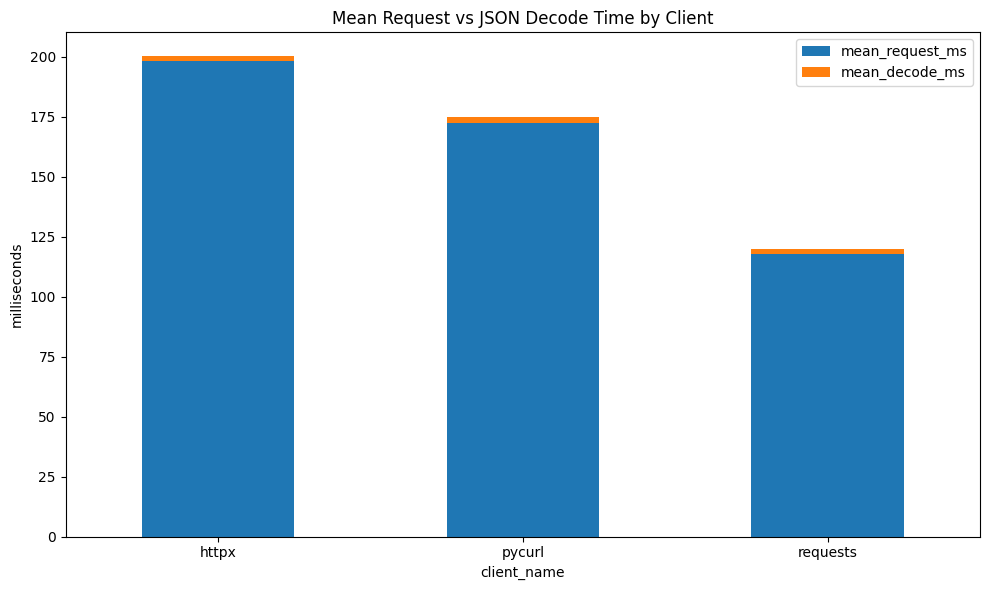

PosixPath('benchmark_results/http_clients_real_fred/figures/request_vs_decode_time_by_client.png')

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_df = client_overview.set_index("client_name")[["mean_request_ms", "mean_decode_ms"]]
plot_df.plot(kind="bar", stacked=True, ax=ax)
ax.set_title("Mean Request vs JSON Decode Time by Client")
ax.set_xlabel("client_name")
ax.set_ylabel("milliseconds")
ax.tick_params(axis="x", rotation=0)
path = savefig("request_vs_decode_time_by_client.png")
plt.show()
path

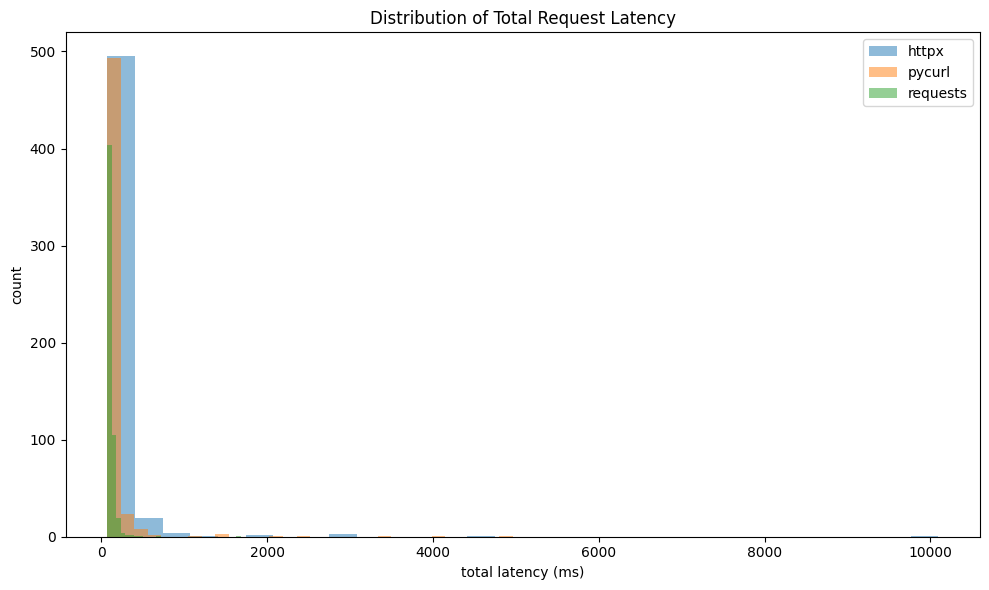

PosixPath('benchmark_results/http_clients_real_fred/figures/total_latency_distribution.png')

In [30]:
fig, ax = plt.subplots(figsize=(10, 6))
for client_name, group in success_df.groupby("client_name"):
    ax.hist(group["total_seconds"] * 1_000, bins=30, alpha=0.5, label=client_name)
ax.set_title("Distribution of Total Request Latency")
ax.set_xlabel("total latency (ms)")
ax.set_ylabel("count")
ax.legend()
path = savefig("total_latency_distribution.png")
plt.show()
path

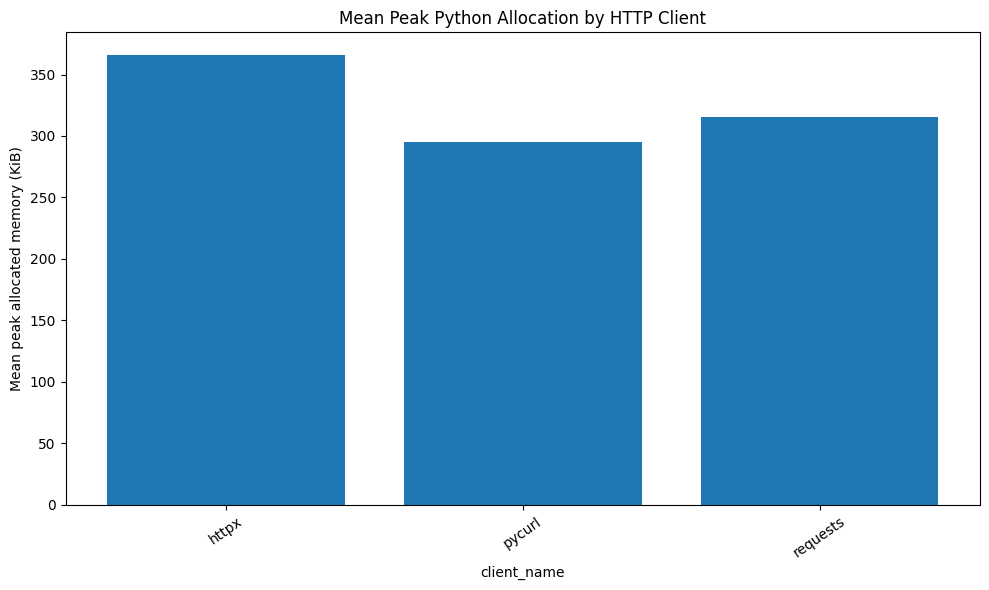

PosixPath('benchmark_results/http_clients_real_fred/figures/mean_peak_allocation_by_client.png')

In [31]:
bar_plot(
    client_overview,
    x="client_name",
    y="mean_peak_alloc_kb",
    title="Mean Peak Python Allocation by HTTP Client",
    ylabel="Mean peak allocated memory (KiB)",
    filename="mean_peak_allocation_by_client.png",
)

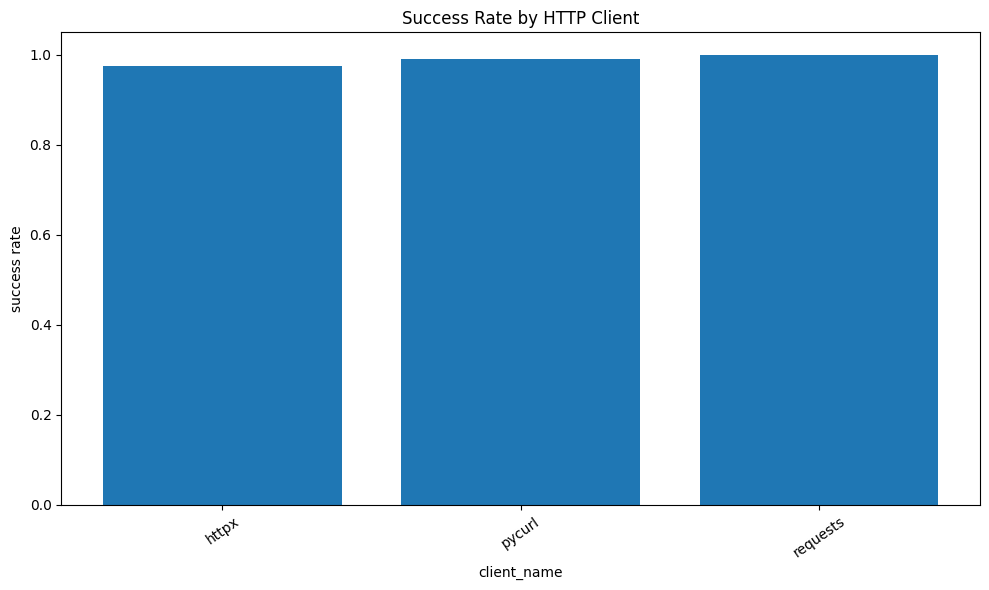

PosixPath('benchmark_results/http_clients_real_fred/figures/success_rate_by_client.png')

In [32]:
bar_plot(
    client_summary,
    x="client_name",
    y="success_rate",
    title="Success Rate by HTTP Client",
    ylabel="success rate",
    filename="success_rate_by_client.png",
)

## 11. Throughput estimate

This benchmark is intentionally polite to the FRED API and includes sleeps. Therefore this section reports two values:

1. **observed throughput**, including sleep and sequencing overhead
2. **client-only throughput estimate**, using measured successful request latency only

The second value is better for client comparison. The first value is better for real notebook runtime planning.

In [33]:
throughput = (
    success_df.groupby("client_name")
    .agg(
        successful_requests=("success", "size"),
        total_measured_seconds=("total_seconds", "sum"),
    )
    .reset_index()
)
throughput["client_only_requests_per_second"] = (
    throughput["successful_requests"] / throughput["total_measured_seconds"]
)
throughput.to_csv(RESULTS_DIR / "throughput_estimates.csv", index=False)
throughput

,client_name,successful_requests,total_measured_seconds,client_only_requests_per_second
0,httpx,526,105.283372,4.996041
1,pycurl,535,93.598613,5.715897
2,requests,540,64.811228,8.331890


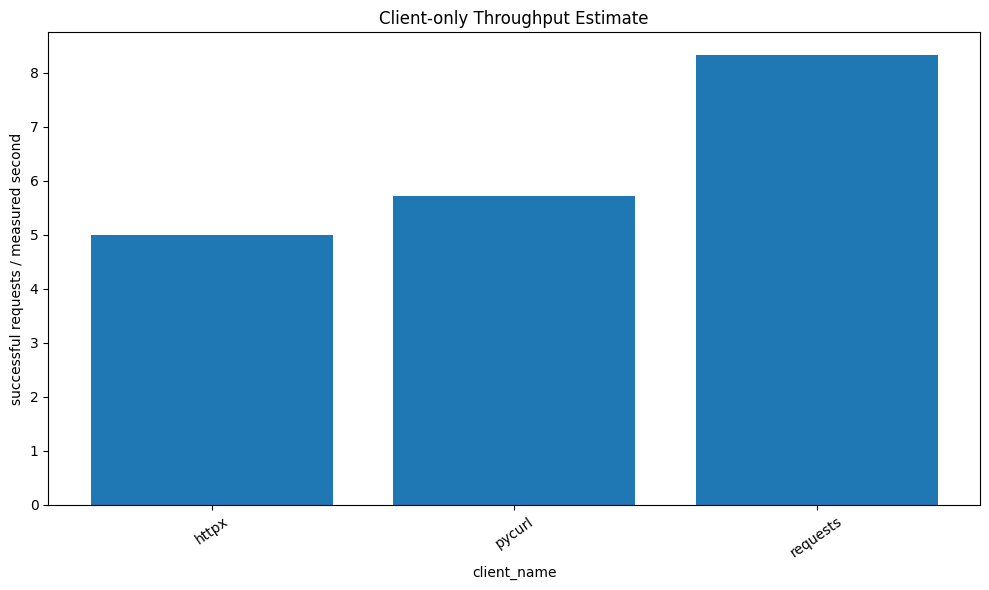

PosixPath('benchmark_results/http_clients_real_fred/figures/client_only_throughput.png')

In [34]:
bar_plot(
    throughput,
    x="client_name",
    y="client_only_requests_per_second",
    title="Client-only Throughput Estimate",
    ylabel="successful requests / measured second",
    filename="client_only_throughput.png",
)

## 12. Series-level stability

This section checks whether the 3 benchmark series are stable or whether one series was affected by transient network/API conditions.

In [35]:
series_stability = (
    success_df.groupby(["client_name", "series"])
    .agg(
        requests=("total_seconds", "size"),
        mean_total_ms=("total_seconds", lambda s: float(s.mean() * 1_000)),
        median_total_ms=("total_seconds", lambda s: float(s.median() * 1_000)),
        p95_total_ms=("total_seconds", lambda s: float(p95(s) * 1_000)),
    )
    .reset_index()
)
series_stability.to_csv(RESULTS_DIR / "series_stability.csv", index=False)
series_stability

,client_name,series,requests,mean_total_ms,median_total_ms,p95_total_ms
0,httpx,1,174,292.562791,115.407833,589.936636
1,httpx,2,172,155.097477,108.014354,222.835778
2,httpx,3,180,153.892669,116.921958,345.481661
3,pycurl,1,175,213.433809,112.968375,477.097900
4,pycurl,2,180,176.850773,115.655104,239.017038
5,pycurl,3,180,135.636426,118.090312,256.501048
6,requests,1,180,132.916163,106.019771,193.866592
7,requests,2,180,111.458356,102.590313,163.965658
8,requests,3,180,115.687860,107.116458,189.326675


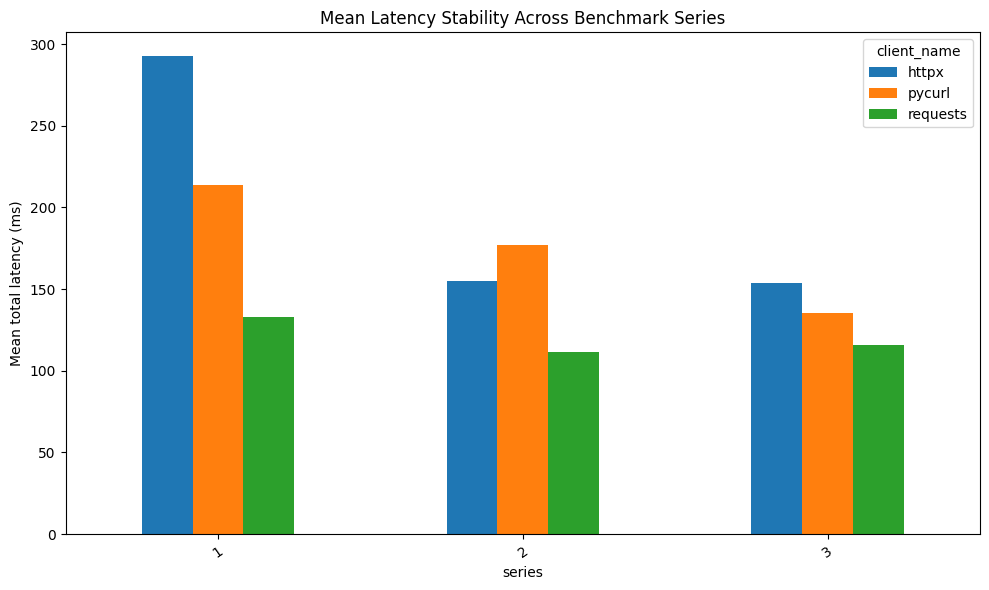

PosixPath('benchmark_results/http_clients_real_fred/figures/series_stability_mean_latency.png')

In [36]:
bar_plot(
    series_stability,
    x="series",
    y="mean_total_ms",
    hue="client_name",
    title="Mean Latency Stability Across Benchmark Series",
    ylabel="Mean total latency (ms)",
    filename="series_stability_mean_latency.png",
)

## 13. Optional: endpoint-normalized comparison

Endpoint mix matters. This table compares clients within each endpoint family.

In [37]:
endpoint_summary = (
    success_df.groupby(["client_name", "endpoint_name"])
    .agg(
        requests=("total_seconds", "size"),
        mean_total_ms=("total_seconds", lambda s: float(s.mean() * 1_000)),
        median_total_ms=("total_seconds", lambda s: float(s.median() * 1_000)),
        p95_total_ms=("total_seconds", lambda s: float(p95(s) * 1_000)),
        mean_payload_kb=("payload_bytes", lambda s: float(s.mean() / 1024)),
    )
    .reset_index()
)
endpoint_summary.to_csv(RESULTS_DIR / "endpoint_summary.csv", index=False)
endpoint_summary

,client_name,endpoint_name,requests,mean_total_ms,median_total_ms,p95_total_ms,mean_payload_kb
0,httpx,series,108,126.955329,95.509708,272.450938,1.471110
1,httpx,series/observations,216,158.620155,121.885083,375.082229,109.477580
2,httpx,series/search,108,388.752081,112.111833,1459.355277,28.741943
3,httpx,series/tags,94,163.032109,113.163625,338.374482,1.789416
4,pycurl,series,108,104.756497,92.653375,161.080196,1.471110
5,pycurl,series/observations,216,180.117243,134.575688,397.676834,109.477580
6,pycurl,series/search,103,295.635754,110.194916,1352.978871,28.840223
7,pycurl,series/tags,108,119.713923,110.357416,171.271779,1.785970
8,requests,series,108,102.956858,94.552979,162.236415,1.471110
9,requests,series/observations,216,131.441794,115.770459,212.273834,109.477580


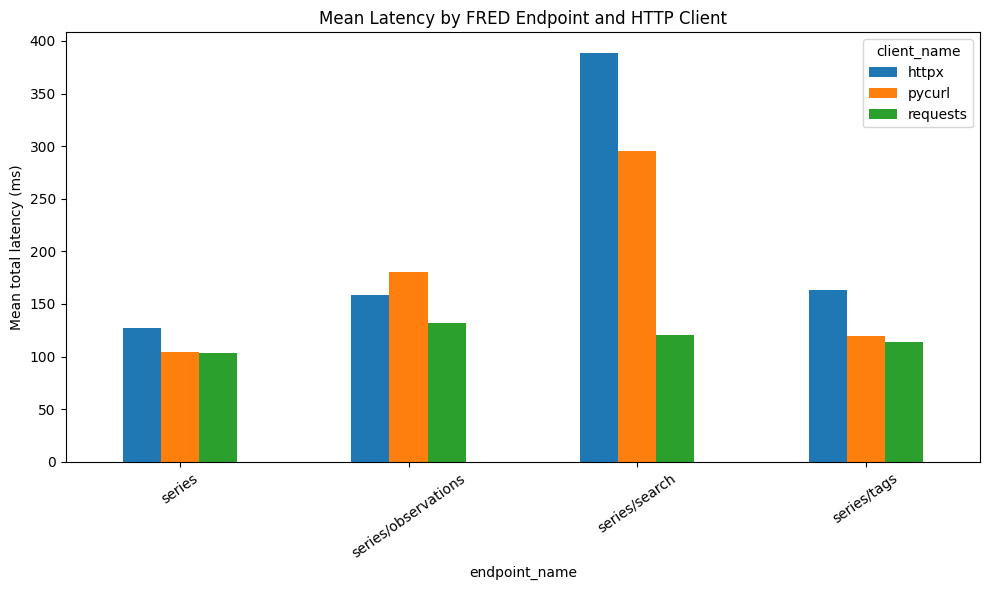

PosixPath('benchmark_results/http_clients_real_fred/figures/endpoint_mean_latency.png')

In [38]:
bar_plot(
    endpoint_summary,
    x="endpoint_name",
    y="mean_total_ms",
    hue="client_name",
    title="Mean Latency by FRED Endpoint and HTTP Client",
    ylabel="Mean total latency (ms)",
    filename="endpoint_mean_latency.png",
)

## 14. Interpretation template

Use the generated tables and figures to write the final interpretation. The decision should not be based only on raw latency. For `fedfred`, the relevant tradeoff is:

| Criterion | `httpx` | `requests` | `pycurl` |
|---|---|---|---|
| Sync support | strong | strong | strong but lower-level |
| Async support | native | none | not ergonomic |
| API ergonomics | modern | very mature | low-level |
| Install burden | moderate | low | high |
| Transport control | strong | moderate | very strong |
| Maintenance burden inside `fedfred` | moderate | low | high |
| Fit for sync/async parity | strongest | weak | weak |

Expected conclusion pattern:

```text
If httpx is close to requests/pycurl in real FRED latency, keep httpx as the default because async support, timeout control, typed API ergonomics, and sync/async parity matter more for fedfred than marginal raw latency differences.

If pycurl is materially faster only on large payloads, treat it as an optional backend rather than the default.

If requests matches httpx on sync latency, it remains a useful baseline but does not solve fedfred's async design goals.
```

## 15. Reproducibility notes

Record the following when reporting benchmark results:

- machine model
- CPU architecture
- Python version
- package versions
- network connection type
- date/time of run
- `FAST_DEV_MODE` value
- number of requests per workload
- whether any FRED errors or non-200 responses occurred

Real API benchmarks are not perfectly deterministic. The notebook therefore emphasizes repeated series, success-rate checks, and endpoint-normalized summaries.

Also record the rate-limit policy used for the run:

- `MAX_REQUESTS_PER_MINUTE`
- `RATE_LIMIT_WINDOW_SECONDS`
- `REST_EVERY_N_REQUESTS`
- `REST_INTERVAL_SECONDS`


In [39]:
import platform
import sys

version_info = pd.DataFrame(
    [
        {"component": "python", "version": sys.version.replace("\n", " ")},
        {"component": "platform", "version": platform.platform()},
        {"component": "machine", "version": platform.machine()},
        {"component": "httpx", "version": getattr(httpx, "__version__", None)},
        {"component": "requests", "version": getattr(requests, "__version__", None)},
        {"component": "pycurl", "version": getattr(pycurl, "version", None)},
        {"component": "pandas", "version": pd.__version__},
        {"component": "numpy", "version": np.__version__},
    ]
)
version_info.to_csv(RESULTS_DIR / "environment_versions.csv", index=False)
version_info

,component,version
0,python,"3.13.13 (main, Apr 7 2026, 18:19:01) [Clang 2..."
1,platform,macOS-26.4.1-arm64-arm-64bit-Mach-O
2,machine,arm64
3,httpx,0.28.1
4,requests,2.33.1
5,pycurl,PycURL/7.46.0 libcurl/8.19.0 OpenSSL/3.6.2 zli...
6,pandas,3.0.2
7,numpy,2.4.4
